- Tipos de datos de las columnas -
ID                         int64
Nombre                       str
Edad                       int64
Nivel_Educativo              str
Salario                  float64
Categoría                    str
Estado                       str
Nivel_Cod                float64
Salario_Normalizado      float64
Años_Hasta_Jubilación      int64
dtype: object

- Visualización del DataFrame procesado -
   ID Nombre  Edad Nivel_Educativo  Salario Categoría    Estado  Nivel_Cod  \
0   1   Juan    32      Licenciado  50000.0    Junior    Activo        0.0   
1   2  María    28       Ingeniero  60000.0    Senior    Activo        1.0   
2   3  Pedro    40       Doctorado  57500.0    Senior  Inactivo        2.0   
3   4    Ana    35      Licenciado  55000.0    Junior    Activo        0.0   

   Salario_Normalizado  Años_Hasta_Jubilación  
0                 0.00                     33  
1                 1.00                     37  
2                 0.75                     

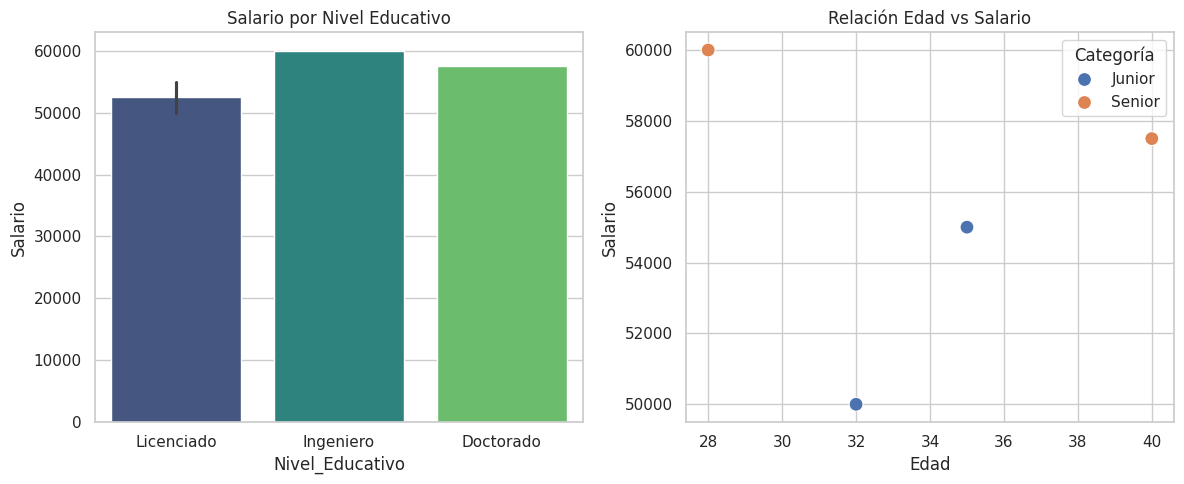

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder

# 0. Creación del DataFrame
df = pd.DataFrame({
    "ID": [1, 2, 3, 4, 5],
    "Nombre": ["Juan", "María", "Pedro", "Ana", "Luis"],
    "Edad": [32, -28, 40, 35, 50],
    "Nivel_Educativo": ["Licenciado", "Ingeniero", "Doctorado", "Licenciado", "Doctorado"],
    "Salario": [50000, 60000, None, 55000, 200000],
    "Categoría": ["Junior", "Senior", "Senior", "Junior", "Manager"],
    "Estado": ["Activo", "ACTIVO", "Inactivo", "Activo", "Inactivo"]
})

# TRATAMIENTO DEL DF

# 1. Corrección de edad negativa
df["Edad"] = df["Edad"].abs()

# 2. Imputación del salario faltante con la mediana (Actualizado para evitar el ChainedAssignmentError)
df["Salario"] = df["Salario"].fillna(df["Salario"].median())

# 3. Detectar y eliminar valores atípicos con IQR
Q1 = df["Salario"].quantile(0.25)
Q3 = df["Salario"].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df["Salario"] < (Q1 - 1.5 * IQR)) | (df["Salario"] > (Q3 + 1.5 * IQR)))]

# 4. Codificación ordinal para "Nivel Educativo"
encoder_ordinal = OrdinalEncoder(categories=[["Licenciado", "Ingeniero", "Doctorado"]])
df["Nivel_Cod"] = encoder_ordinal.fit_transform(df[["Nivel_Educativo"]])

# 5. Normalización del salario
scaler = MinMaxScaler()
df["Salario_Normalizado"] = scaler.fit_transform(df[["Salario"]])

# 6. Creación de nueva variable "Años hasta jubilación"
df["Años_Hasta_Jubilación"] = 65 - df["Edad"]

# 7. Consistencia de tipeo en "Estado"
df["Estado"] = df["Estado"].str.capitalize()

# TAREAS A REALIZAR 

# 1. Identificación de Tipos de Datos
print("- Tipos de datos de las columnas -")
print(df.dtypes)
print("\n- Visualización del DataFrame procesado -")
print(df)

# --- ANÁLISIS EXPLORATORIO (EDA) ---

# Configuración visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

# Visualización 1: Salario por Nivel Educativo (Actualizado para evitar el FutureWarning)
plt.subplot(1, 2, 1)
sns.barplot(
    data=df, 
    x="Nivel_Educativo", 
    y="Salario", 
    hue="Nivel_Educativo", 
    palette="viridis", 
    legend=False
)
plt.title("Salario por Nivel Educativo")

# Visualización 2: Relación Edad y Salario
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x="Edad", y="Salario", hue="Categoría", s=100)
plt.title("Relación Edad vs Salario")

plt.tight_layout()
plt.show()

### 1. Identificación de Tipos de Datos y Criterios de Manejo

| Columna | Tipo de Dato | Naturaleza | Manejo y Justificación |
| :--- | :--- | :--- | :--- |
| **ID** | Numérico | Identificador | **Descartar:** No tiene valor predictivo para el modelo. |
| **Nombre** | Categórico | Nominal | **Descartar:** Datos únicos que causarían sobreajuste. |
| **Edad** | Numérico | Discreto | **Limpieza:** Se aplicó `.abs()` para corregir valores negativos. |
| **Nivel_Educativo** | Categórico | **Ordinal** | **Ordinal Encoding:** Se respeta la jerarquía (Lic < Ing < Doc). |
| **Salario** | Numérico | Continuo | **Limpieza:** Imputación de nulos (mediana) y remoción de outliers (IQR). |
| **Categoría** | Categórico | Nominal | **Mantenimiento:** Representa el rango laboral del empleado. |
| **Estado** | Categórico | Nominal | **Estandarización:** Unificación de formato con `.capitalize()`. |